# TF-IDF Baseline + Per-Category Metrics - Jeslyn Chang

This notebook trains the first clause classifier and measures how well it does on each of the 41 categories.

1. Rebuilds the TF-IDF features exactly as in `Vectorization.ipynb`
2. Trains a **one-vs-rest logistic regression**: one yes/no classifier per clause category
3. Reports **precision, recall and F1 per category** on the test set
4. Flags the **weak** and **rare** categories

This is the baseline that the fine-tuned transformer in Milestone 2 has to beat.

In [1]:
import json, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import precision_recall_fscore_support

## 1. Load the labeled chunks

Same files as `Vectorization.ipynb`: one row per chunk, with `chunk_text` and one 0/1 column for each of the 41 categories.

In [2]:
DATA_DIR = '../data/processed'

if not os.path.exists(DATA_DIR):
    try:
        # Google Colab: upload the 3 files from data/processed/
        from google.colab import files
    except ImportError:
        raise FileNotFoundError(f"{DATA_DIR} not found. Run `git merge origin/main` to get the labeled chunks from Labeling.ipynb.")
    files.upload()
    DATA_DIR = '.'

In [3]:
train_df = pd.read_parquet(f'{DATA_DIR}/train_chunks_labeled.parquet')
test_df = pd.read_parquet(f'{DATA_DIR}/test_chunks_labeled.parquet')
with open(f'{DATA_DIR}/categories.json', 'r') as file:
    CATEGORIES = json.load(file)

print("Train chunks:", train_df.shape)   # expect (14181, 46)
print("Test chunks: ", test_df.shape)    # expect (2898, 46)
print("Categories:  ", len(CATEGORIES))  # expect 41

Train chunks: (14181, 46)
Test chunks:  (2898, 46)
Categories:   41


## 2. TF-IDF features

`Vectorization.ipynb` doesn't save `X_train` / `X_test` to disk, so I rebuild them here with the **same tokenizer and the same settings** (1–2 word phrases, `min_df=5`, `sublinear_tf=True`, no stopwords removed). As before, the vectorizer is fit on **train only** and then applied to test.

In [4]:
TOKEN_PATTERN = r"\$\s*\d+(?:[.,]\d+)*|\d+(?:[.,]\d+)*|[a-z]+(?:[-'][a-z]+)*"

def tokenize_words(text):
    tokens = re.findall(TOKEN_PATTERN, text.lower())
    cleaned = []
    for token in tokens:
        if token.startswith("$"):
            cleaned.append("<money>")
        elif token[0].isdigit():
            cleaned.append("<num>")
        else:
            cleaned.append(token)
    return cleaned

vectorizer = TfidfVectorizer(
    tokenizer=tokenize_words,
    lowercase=False,        # tokenize_words already lowercases
    token_pattern=None,     # not used, since we give our own tokenizer
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(train_df['chunk_text'])
X_test = vectorizer.transform(test_df['chunk_text'])
y_train = train_df[CATEGORIES].to_numpy()
y_test = test_df[CATEGORIES].to_numpy()

print("X_train:", X_train.shape, " y_train:", y_train.shape)   # expect (14181, 98157) and (14181, 41)
print("X_test: ", X_test.shape, " y_test: ", y_test.shape)     # expect (2898, 98157) and (2898, 41)

X_train: (14181, 98157)  y_train: (14181, 41)
X_test:  (2898, 98157)  y_test:  (2898, 41)


## 3. Train the one-vs-rest logistic regression

A chunk can contain **several** clause types at once (e.g. *Governing Law* and *Notice Period*), so this is a **multi-label** problem. One-vs-rest handles it by training **41 separate yes/no classifiers**, one per category. Each one learns which words and phrases push a chunk toward "yes, this category is here".

**Settings:**
- `class_weight='balanced'`: most categories are positive in only 1–5% of chunks. Without this, a classifier can score well by almost always saying "no". Balancing makes each missed positive cost more.
- `solver='liblinear'`: fast and reliable for sparse TF-IDF features with a yes/no target
- `C=1.0` (the default regularization strength) and a **0.5 probability threshold**. We have no separate validation set, and tuning these on the test set would make the scores look better than they really are. Tuning belongs in Milestone 2, on a validation split carved out of train.

In [5]:
model = OneVsRestClassifier(
    LogisticRegression(class_weight='balanced', solver='liblinear', C=1.0, max_iter=1000),
    n_jobs=-1,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Predictions:", y_pred.shape)   # one 0/1 per chunk per category

Predictions: (2898, 41)


## 4. Per-category precision, recall and F1

For each category, on the **test** chunks:
- **Precision:** of the chunks the model flagged, how many really contain the clause? (Low precision means a reviewer wastes time on false alarms.)
- **Recall:** of the chunks that really contain the clause, how many did the model find? (Low recall means a reviewer misses clauses. This matters more for risk review.)
- **F1:** a single score that balances precision and recall

`test_support` is the number of test chunks that truly contain the category. **Price Restrictions has 0 test positives**, so its recall and F1 are undefined. I set them to `NaN` instead of 0 so they don't drag down the averages.

In [6]:
precision, recall, f1, test_support = precision_recall_fscore_support(
    y_test, y_pred, average=None, zero_division=0
)

results = pd.DataFrame({
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'test_support': test_support,
    'train_support': y_train.sum(axis=0),
}, index=CATEGORIES)

# No test positives -> recall and F1 can't be measured
no_test_positives = results['test_support'] == 0
results.loc[no_test_positives, ['recall', 'f1']] = np.nan
print("No test positives:", list(results.index[no_test_positives]))

results.sort_values('f1', ascending=False).round(3)

No test positives: ['Price Restrictions']


,precision,recall,f1,test_support,train_support
Parties,0.709,0.864,0.779,147,548
Governing Law,0.672,0.891,0.766,138,521
Anti-Assignment,0.651,0.809,0.721,136,588
Audit Rights,0.698,0.713,0.705,94,486
Insurance,0.685,0.704,0.694,71,298
License Grant,0.580,0.836,0.685,152,701
Renewal Term,0.552,0.881,0.679,42,234
Expiration Date,0.583,0.793,0.672,111,525
Cap On Liability,0.595,0.770,0.671,122,640
Agreement Date,0.540,0.870,0.667,100,408


**Overall scores.** *Micro* pools every chunk-category decision together, so common categories count more. *Macro* is the plain average of the per-category scores, so every category counts equally. Macro is the better guide to how the model does on rare clauses.

In [7]:
measurable = ~no_test_positives.to_numpy()

overall = {}
for average in ['micro', 'macro']:
    p, r, f, _ = precision_recall_fscore_support(
        y_test[:, measurable], y_pred[:, measurable], average=average, zero_division=0
    )
    overall[average] = {'precision': p, 'recall': r, 'f1': f}

overall = pd.DataFrame(overall).T
print(f"Averaged over the {measurable.sum()} categories that have test positives:")
overall.round(3)

Averaged over the 40 categories that have test positives:


,precision,recall,f1
micro,0.519,0.686,0.591
macro,0.511,0.584,0.517


## 5. Weak and rare categories

- **Weak:** test F1 below **0.5**, so the model gets less than half of it right
- **Rare:** fewer than **100** positive chunks in train, so the model has few examples to learn from
- **Few test examples:** fewer than **20** positive chunks in test. Its F1 is noisy, because one chunk more or less changes the score a lot.

In [8]:
WEAK_F1 = 0.5
RARE_TRAIN = 100
FEW_TEST = 20

results['weak'] = results['f1'] < WEAK_F1
results['rare'] = results['train_support'] < RARE_TRAIN
results['few_test'] = results['test_support'] < FEW_TEST

print(f"Weak categories (F1 < {WEAK_F1}): {results['weak'].sum()} of {measurable.sum()}")
print(f"Rare categories (< {RARE_TRAIN} train positives): {results['rare'].sum()}")
print(f"Weak AND rare: {(results['weak'] & results['rare']).sum()}")

Weak categories (F1 < 0.5): 15 of 40
Rare categories (< 100 train positives): 10
Weak AND rare: 4


In [9]:
weak_or_rare = results[results['weak'] | results['rare'] | no_test_positives]
weak_or_rare.sort_values('f1').round(3)

,precision,recall,f1,test_support,train_support,weak,rare,few_test
Unlimited/All-You-Can-Eat-License,0.000,0.000,0.000,5,31,True,True,True
Most Favored Nation,0.000,0.000,0.000,5,51,True,True,True
Competitive Restriction Exception,0.333,0.161,0.217,31,120,True,False,False
Non-Disparagement,0.667,0.133,0.222,15,64,True,True,True
Third Party Beneficiary,0.429,0.200,0.273,15,42,True,True,True
Post-Termination Services,0.287,0.565,0.381,85,418,True,False,False
Volume Restriction,0.458,0.333,0.386,33,148,True,False,False
Ip Ownership Assignment,0.320,0.508,0.393,65,263,True,False,False
Change Of Control,0.387,0.446,0.414,65,210,True,False,False
Effective Date,0.372,0.515,0.432,99,408,True,False,False


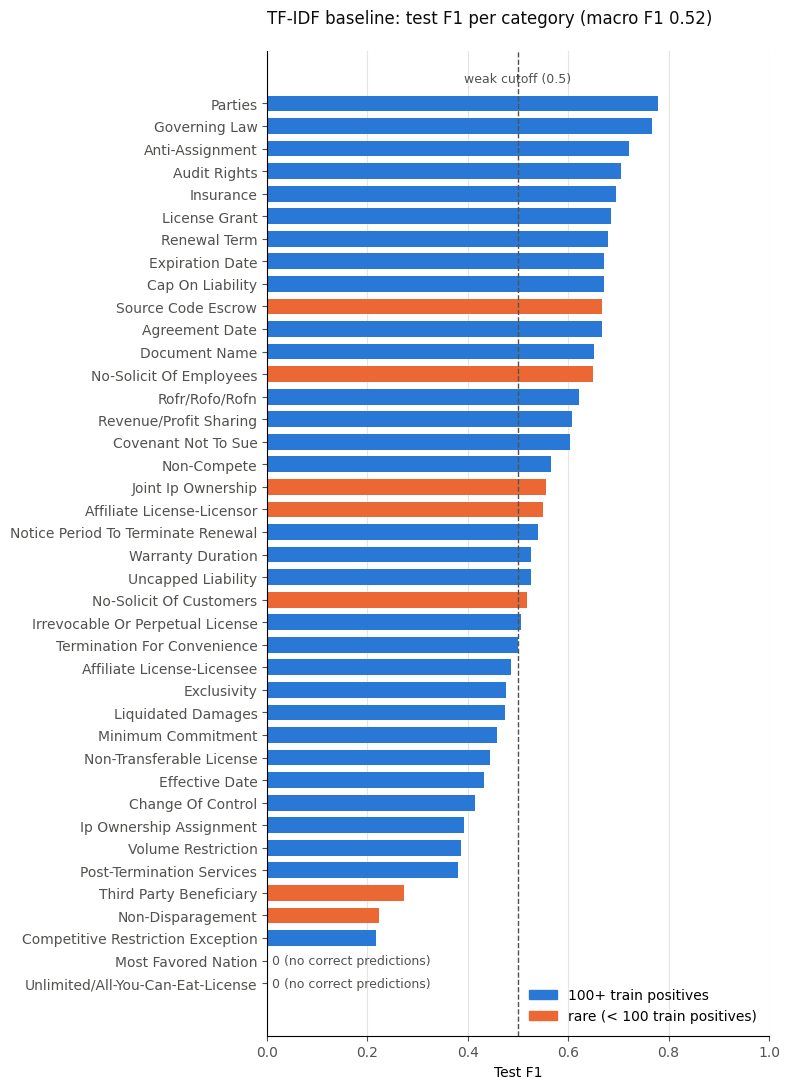

Correlation between train positives and F1: 0.57


In [10]:
plot_df = results.dropna(subset=['f1']).sort_values('f1')
BLUE, ORANGE, INK, MUTED = '#2a78d6', '#eb6834', '#0b0b0b', '#52514e'
colors = [ORANGE if rare else BLUE for rare in plot_df['rare']]

fig, ax = plt.subplots(figsize=(8, 11))
ax.barh(plot_df.index, plot_df['f1'], color=colors, height=0.7)
ax.axvline(WEAK_F1, color=MUTED, linestyle='--', linewidth=1)
ax.text(WEAK_F1, len(plot_df) - 0.2, 'weak cutoff (0.5)', color=MUTED, fontsize=9, ha='center', va='bottom')
for position, (category, row) in enumerate(plot_df.iterrows()):
    if row['f1'] == 0:
        ax.text(0.01, position, '0 (no correct predictions)', color=MUTED, fontsize=9, va='center')

ax.set_xlim(0, 1)
ax.set_xlabel('Test F1')
ax.set_title(f"TF-IDF baseline: test F1 per category (macro F1 {overall.loc['macro', 'f1']:.2f})", loc='left', color=INK, pad=20)
ax.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color=BLUE, label=f'{RARE_TRAIN}+ train positives'),
    plt.Rectangle((0, 0), 1, 1, color=ORANGE, label=f'rare (< {RARE_TRAIN} train positives)'),
], loc='lower right', frameon=False)
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
ax.tick_params(colors=MUTED)
ax.grid(axis='x', color='#e5e4e0', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"Correlation between train positives and F1: {plot_df['train_support'].corr(plot_df['f1']):.2f}")

**Precision or recall: which one is low?** For the weak categories, this shows whether the model raises too many false alarms (low precision) or misses real clauses (low recall). The two problems need different fixes.

In [11]:
weak = results[results['weak']].copy()
weak['main_problem'] = np.where(weak['precision'] < weak['recall'], 'low precision (false alarms)', 'low recall (misses)')
weak.sort_values('f1')[['precision', 'recall', 'f1', 'train_support', 'test_support', 'main_problem']].round(3)

,precision,recall,f1,train_support,test_support,main_problem
Most Favored Nation,0.000,0.000,0.000,51,5,low recall (misses)
Unlimited/All-You-Can-Eat-License,0.000,0.000,0.000,31,5,low recall (misses)
Competitive Restriction Exception,0.333,0.161,0.217,120,31,low recall (misses)
Non-Disparagement,0.667,0.133,0.222,64,15,low recall (misses)
Third Party Beneficiary,0.429,0.200,0.273,42,15,low recall (misses)
Post-Termination Services,0.287,0.565,0.381,418,85,low precision (false alarms)
Volume Restriction,0.458,0.333,0.386,148,33,low recall (misses)
Ip Ownership Assignment,0.320,0.508,0.393,263,65,low precision (false alarms)
Change Of Control,0.387,0.446,0.414,210,65,low precision (false alarms)
Effective Date,0.372,0.515,0.432,408,99,low precision (false alarms)


**What the model looks at.** The highest-weight words for a strong category and a weak category. For a strong category the words are specific to that clause. For a weak one they are generic or overlap with other clause types, which explains the false alarms.

In [12]:
vocab = vectorizer.get_feature_names_out()

def top_features(category, n=10):
    classifier = model.estimators_[CATEGORIES.index(category)]
    top = classifier.coef_[0].argsort()[::-1][:n]
    return ', '.join(vocab[top])

for category in ['Governing Law', 'Anti-Assignment', 'Post-Termination Services',
                 'Competitive Restriction Exception', 'Most Favored Nation']:
    print(f"{category} (F1 {results.loc[category, 'f1']:.2f}):\n  {top_features(category)}\n")

Governing Law (F1 0.77):
  governed, laws of, the laws, the state, governed by, be governed, state of, governing law, laws, governing

Anti-Assignment (F1 0.72):
  assign, assignment, consent, written consent, consent of, <num> assignment, without the, transfer, prior written, the prior

Post-Termination Services (F1 0.38):
  termination, of termination, termination of, expiration, upon termination, or expiration, termination or, such termination, continue, date of

Competitive Restriction Exception (F1 0.22):
  exclusivity, exclusive, the exclusivity, products, <num> exclusivity, comware, the exclusive, restrictions, consultant, shall not

Most Favored Nation (F1 0.00):
  favorable, more favorable, pricing, than, prices, <num> most, price, into, favourable, most



## 6. Summary

**What this notebook does:** trains a one-vs-rest logistic regression (41 yes/no classifiers, `class_weight='balanced'`) on the TF-IDF features from `Vectorization.ipynb`, and evaluates each category on the 2,898 test chunks.

**Overall results** (40 categories; Price Restrictions has no test positives):

| | Precision | Recall | F1 |
|---|---|---|---|
| Micro | 0.519 | 0.686 | 0.591 |
| Macro | 0.511 | 0.584 | 0.517 |

Recall is higher than precision because of `class_weight='balanced'`: the model would rather flag a chunk than miss a clause. For contract review that is the right direction, since a missed clause costs more than a false alarm.

**Strong categories (F1 ≥ 0.65):** Parties, Governing Law, Anti-Assignment, Audit Rights, Insurance, License Grant, Renewal Term, Expiration Date, Cap On Liability, Agreement Date, Document Name. These clauses use fixed, distinctive wording (*governed by the laws of*, *prior written consent*, *liability insurance*), which word counts capture well.

**Weak categories (F1 < 0.5): 15 of 40.** They fail in two different ways:
- **Low recall (misses):** Most Favored Nation and Unlimited/All-You-Can-Eat-License (F1 0, only 31–51 train examples), Competitive Restriction Exception, Non-Disparagement, Third Party Beneficiary, Volume Restriction, Liquidated Damages. These are mostly rare. Most Favored Nation and Unlimited License **never predict yes on test**, even though their top words are the right ones (*more favorable*, *unlimited*), so their probabilities never reach the 0.5 threshold. A lower per-category threshold should help. Liquidated Damages has 0.90 precision but finds only a third of the clauses.
- **Low precision (false alarms):** Post-Termination Services, IP Ownership Assignment, Change Of Control, Effective Date, Non-Transferable License, Minimum Commitment, Exclusivity, Affiliate License-Licensee. These have plenty of examples, but their key words are shared with other clauses. Post-Termination Services keys on *termination* and *expiration*, which also appear in every termination clause. Competitive Restriction Exception borrows words from Exclusivity. A bag of words can't tell "an exception to a restriction" from "a restriction".

**Rare categories (< 100 train positives): 10.** Unlimited/All-You-Can-Eat-License, Price Restrictions, Third Party Beneficiary, Source Code Escrow, Most Favored Nation, No-Solicit Of Customers, Affiliate License-Licensor, Non-Disparagement, No-Solicit Of Employees, Joint IP Ownership.
- 4 of them are also weak. Train size and F1 are correlated (0.57), but size isn't everything: several rare categories with distinctive vocabulary (Source Code Escrow → *escrow*, No-Solicit Of Employees → *solicit*, *employee*) still score above 0.5.
- **Test scores for rare categories are unreliable.** Most have fewer than 20 test positives (Source Code Escrow has 2), so one chunk more or less moves F1 a lot. **Price Restrictions can't be evaluated at all.**

**Limitations:**
- Scores are **per chunk**, not per contract. A clause split across two chunks counts twice.
- No hyperparameter tuning: `C=1.0` and threshold 0.5 are defaults, chosen without looking at test.

**Next steps for Milestone 2:**
- Hold out a **validation split** from train (grouped by contract) to tune `C` and a **per-category threshold**. That should help the low-precision categories most.
- The transformer should help where word context matters: exceptions, negation, and termination-related clauses that share vocabulary.
- For rare categories, try oversampling or data augmentation, and report them with confidence intervals or at the contract level, since the test counts are too small.